In [1]:
import numpy as np
import cv2
import random
from IPython.display import Image

In [2]:
#load cascade files
face_cascade=cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
mouth_cascade=cv2.CascadeClassifier('haarcascade_mcs_mouth.xml')

In [3]:
#Initialize
font=cv2.FONT_HERSHEY_SIMPLEX
white=(255,255,255)
red=(0,0,255)
blue=(255,0,0)
thickness=2
fontSize=0.8

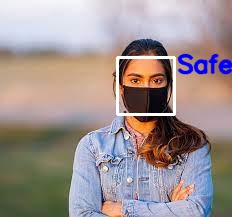

In [4]:
img=cv2.imread("image1.jpg")
#convert images to gray

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


#detect face
faces=face_cascade.detectMultiScale(gray,1.1,4)

#if face detected
if(len(faces)>0):
    #draw rectangle on face
    for(x,y,w,h) in faces:
        cv2.rectangle(img,(x,y),(x+w,y+h),white,thickness)
        roi_gray=gray[y:y+h,x:x+w]
        roi_color=img[y:y+h,x:x+w]
        
        #detect lips
        mouth_boundary=mouth_cascade.detectMultiScale(gray,1.5,5)
        
        #face detected but lips not detected which means person is wearing mask
        if(len(mouth_boundary)==0):
            cv2.putText(img,"Safe",(x+60,y+15),font,fontSize,blue,thickness,cv2.LINE_AA)
        else:
            for(mx,my,mw,mh) in mouth_boundary:
                
                #face and lips are detected
                #if lip coordinates are within face coordinates means lip prediction is true and that person is wearing mask
                if(y<my<y+h):
                    cv2.putText(img,"Danger!!No Mask",(mx,my),font,fontSize,red,thickness,cv2.LINE_AA)
                    
#show frame with results
cv2.imwrite("MaskDetection.jpg",img)
display(Image(filename="MaskDetection.jpg"))